# Global Data on Sustainable Energy (2000-2020)

This notebook did an Exploratory Data Analysis (EDA) on the **Global Data on Sustainable Energy** dataset, connected to **SDG 7: Affordable and Clean Energy**. The primary EDA was did on energy and economic across countries from 2000 to 2020.


**Steps in this notebook:**
1. Load the raw data and check for missing values
2. Drop columns with too many missing values or not relevant to the analysis
3. Clean and impute the remaining columns
4. Visualize the cleaned data to find insights

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('darkgrid')

In [74]:
df = pd.read_csv('raw_dataset.csv')

In [75]:
df.columns

Index(['Entity', 'Year', 'Access to electricity (% of population)',
       'Access to clean fuels for cooking',
       'Renewable-electricity-generating-capacity-per-capita',
       'Financial flows to developing countries (US $)',
       'Renewable energy share in the total final energy consumption (%)',
       'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)',
       'Electricity from renewables (TWh)',
       'Low-carbon electricity (% electricity)',
       'Primary energy consumption per capita (kWh/person)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Value_co2_emissions_kt_by_country',
       'Renewables (% equivalent primary energy)', 'gdp_growth',
       'gdp_per_capita', 'Density\n(P/Km2)', 'Land Area(Km2)', 'Latitude',
       'Longitude'],
      dtype='str')

## Step 1: Check Missing Values

Before deciding which columns to keep, we check how much data is missing in each column.

In [76]:
df.isna().sum()

Entity                                                                 0
Year                                                                   0
Access to electricity (% of population)                               10
Access to clean fuels for cooking                                    169
Renewable-electricity-generating-capacity-per-capita                 931
Financial flows to developing countries (US $)                      2089
Renewable energy share in the total final energy consumption (%)     194
Electricity from fossil fuels (TWh)                                   21
Electricity from nuclear (TWh)                                       126
Electricity from renewables (TWh)                                     21
Low-carbon electricity (% electricity)                                42
Primary energy consumption per capita (kWh/person)                     0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          207
Value_co2_emissions_kt_by_country                  

In [77]:
df.isna().mean() * 100

Entity                                                               0.000000
Year                                                                 0.000000
Access to electricity (% of population)                              0.274048
Access to clean fuels for cooking                                    4.631406
Renewable-electricity-generating-capacity-per-capita                25.513839
Financial flows to developing countries (US $)                      57.248561
Renewable energy share in the total final energy consumption (%)     5.316525
Electricity from fossil fuels (TWh)                                  0.575500
Electricity from nuclear (TWh)                                       3.453001
Electricity from renewables (TWh)                                    0.575500
Low-carbon electricity (% electricity)                               1.151000
Primary energy consumption per capita (kWh/person)                   0.000000
Energy intensity level of primary energy (MJ/$2017 PPP GDP)     

Dropping the columns which has 50%> Missing data

In [78]:
df.drop(columns=['Renewables (% equivalent primary energy)', 'Financial flows to developing countries (US $)',], inplace=True)

Dropping the columns that won't be used to find the insights

In [79]:
df.drop(columns=['Access to clean fuels for cooking', 
                 'Electricity from fossil fuels (TWh)', 
                 'Renewable-electricity-generating-capacity-per-capita', 
                 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 
                 'Low-carbon electricity (% electricity)', 'Value_co2_emissions_kt_by_country', 
                 'Land Area(Km2)',
                 'Density\\n(P/Km2)',
                 'Latitude',
                 'Longitude'
                ], inplace=True)

In [80]:
df

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),gdp_growth,gdp_per_capita
0,Afghanistan,2000,1.613591,44.99,302.59482,1.64,NaN,NaN
1,Afghanistan,2001,4.074574,45.60,236.89185,1.74,NaN,NaN
2,Afghanistan,2002,9.409158,37.83,210.86215,1.40,NaN,179.426579
3,Afghanistan,2003,14.738506,36.66,229.96822,1.40,8.832278,190.683814
4,Afghanistan,2004,20.064968,44.24,204.23125,1.20,1.414118,211.382074
...,...,...,...,...,...,...,...,...
3644,Zimbabwe,2016,42.561730,81.90,3227.68020,10.00,0.755869,1464.588957
3645,Zimbabwe,2017,44.178635,82.46,3068.01150,9.51,4.709492,1235.189032
3646,Zimbabwe,2018,45.572647,80.23,3441.98580,9.83,4.824211,1254.642265
3647,Zimbabwe,2019,46.781475,81.50,3003.65530,10.47,-6.144236,1316.740657


#### Key Features:  

Entity: The name of the country or region for which the data is reported.  

Year: The year for which the data is reported, ranging from 2000 to 2020.

Access to electricity (% of population): The percentage of population with access to electricity.  

Renewable energy share in total final energy consumption (%): Percentage of renewable energy in final energy consumption.  

Energy intensity level of primary energy (MJ/$2011 PPP GDP): Energy use per unit of GDP at purchasing power parity.  

GDP growth (annual %): Annual GDP growth rate based on constant local currency.  

GDP per capita: Gross domestic product per person.  

## Data Cleaning

### Access to electricity

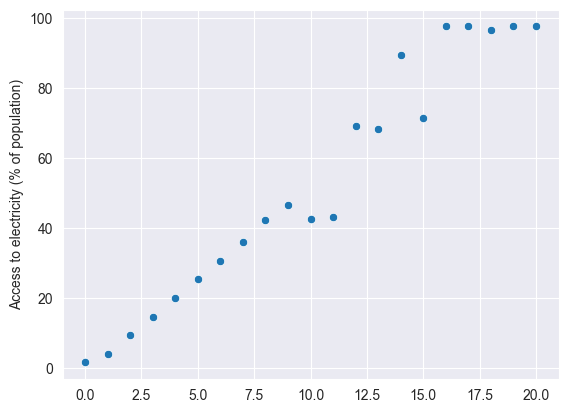

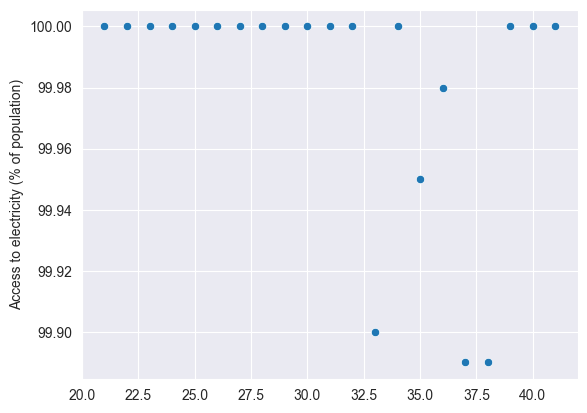

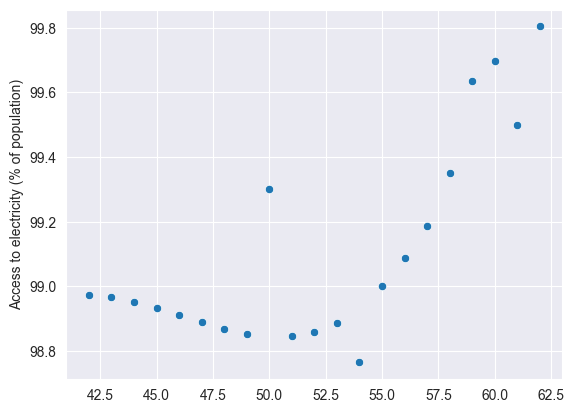

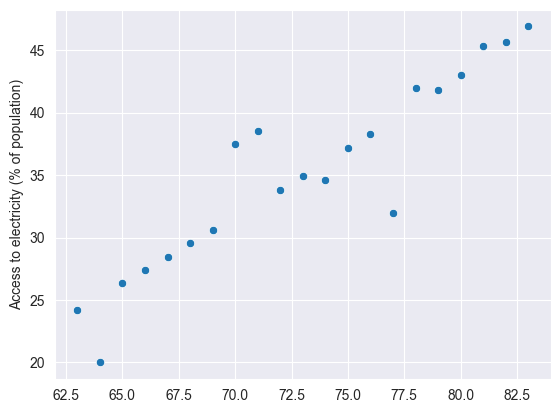

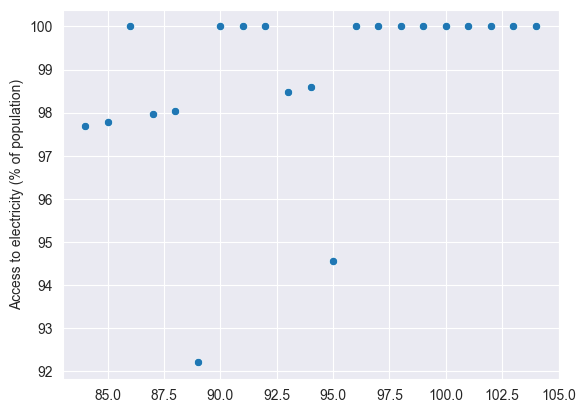

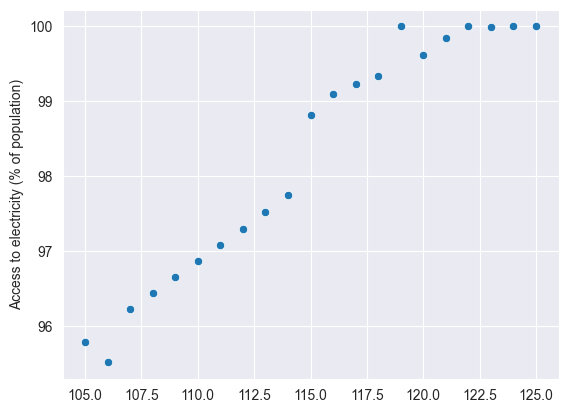

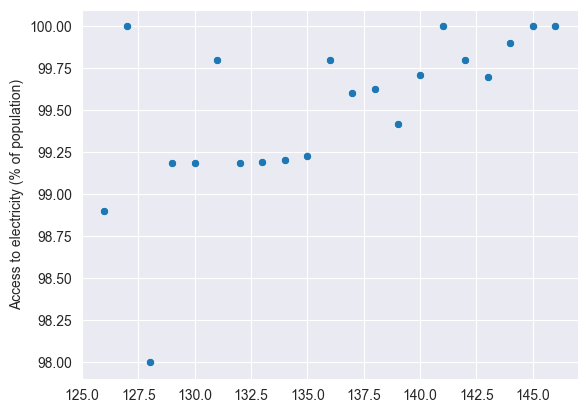

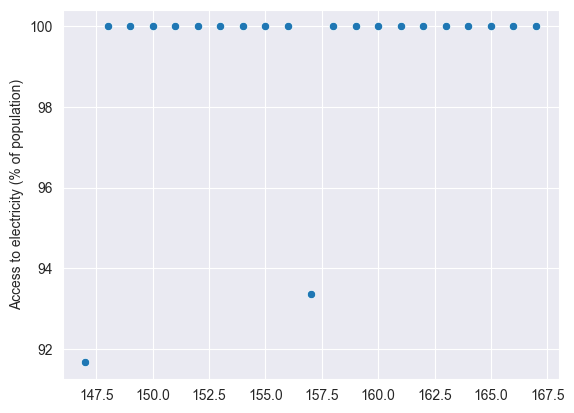

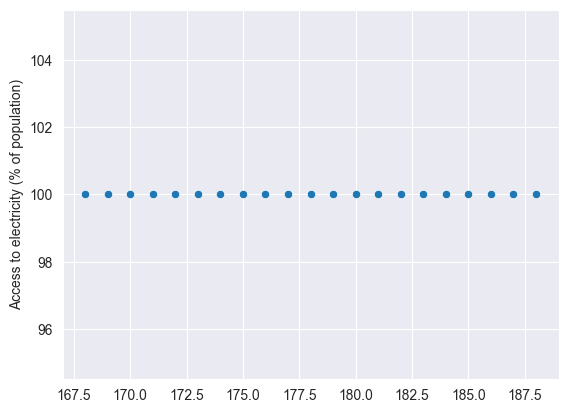

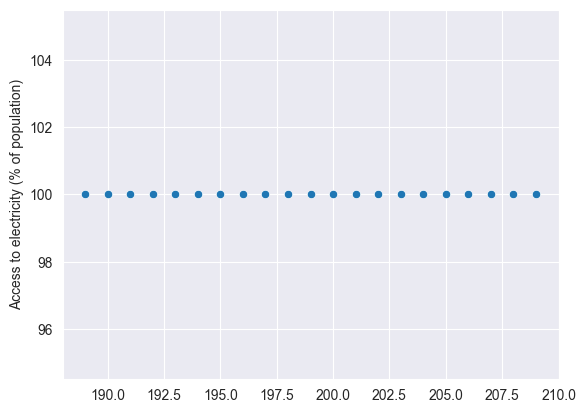

In [81]:
col = 'Access to electricity (% of population)'
for i in df[df[col].notna()]['Entity'].unique()[:10]:
    plt.figure()
    sns.scatterplot(df[df['Entity'] == i][col])

In [82]:
df[df['Access to electricity (% of population)'].notna()]['Entity'].unique()[:5]

<StringArray>
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda']
Length: 5, dtype: str

Access to electricity is highly correlated with the column "Access to clean fuels for cooking", with only 10 of the data missing. therefore, with a highly correlated data, linear regression prediction would be a go to method of imputation

In [83]:
col = 'Access to electricity (% of population)'
impute= []
for i in df[df[col].isna()]['Entity'].unique():
    if (df[df[col].notna() & (df['Entity'] == i)][col].count()) > 5:
        impute.append(i)

In [84]:
from sklearn.linear_model import LinearRegression
col = 'Access to electricity (% of population)'
for i in impute:
    lm = LinearRegression()
    data_train = df[(df['Entity'] == i) & (df[col].notna())]
    X_train = data_train[['Year']]
    y_train = data_train[col]

    lm.fit(X_train, y_train)
    data_missing = df[(df['Entity'] == i) & (df[col].isna())]
    
    #Check if there is a missing value in a row
    if not data_missing.empty:
        X_test = data_missing[['Year']]
        predictions = lm.predict(X_test)
        df.loc[data_missing.index, col] = predictions
    else:
        continue

NOTE: Linear Regression imputation sometimes produces values outside the natural range of 0–100% (for example, negative values for early years). We clip the values to keep them within the valid range.

In [85]:
df['Access to electricity (% of population)'] = df['Access to electricity (% of population)'].clip(lower=0, upper=100)

In [86]:
df['Access to electricity (% of population)'].isna().sum()

np.int64(1)

In [87]:
df.loc[df['Access to electricity (% of population)'].isna()]

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),gdp_growth,gdp_per_capita
1218,French Guiana,2000,NaN,23.84,13692.394,NaN,NaN,NaN


In [88]:
df[df['Entity'] == 'French Guiana']

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),gdp_growth,gdp_per_capita
1218,French Guiana,2000,NaN,23.84,13692.394,NaN,NaN,NaN


In [89]:
# Apparently french guiana only has only one entry in the whole dataset with a lot of NaN features, it would be wise to drop the row
df= df.drop(index=1218)

In [90]:
df.isna().sum()

Entity                                                                0
Year                                                                  0
Access to electricity (% of population)                               0
Renewable energy share in the total final energy consumption (%)    194
Primary energy consumption per capita (kWh/person)                    0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         206
gdp_growth                                                          316
gdp_per_capita                                                      281
dtype: int64

### Renewable energy share in the total final energy consumption (%)

In [91]:
missing_counts = df[df['Renewable energy share in the total final energy consumption (%)'].isna()].groupby('Entity').size()
emptylist = missing_counts[missing_counts < 5].index.tolist()
emptylist

['Afghanistan',
 'Algeria',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guatemala',
 'Guinea',
 'Guinea-Bissau',
 'Guyana',
 'Haiti',
 'Honduras',
 'Hungary',
 'Iceland',
 'India',
 'Indonesia',
 'Iraq',
 'Ireland',
 'Israel',
 

In [92]:
df[df['Renewable energy share in the total final energy consumption (%)'].isna()]

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),gdp_growth,gdp_per_capita
20,Afghanistan,2020,97.700000,NaN,702.8880,NaN,-2.351101,516.747871
21,Albania,2000,100.000000,NaN,9029.4375,4.13,6.946217,1126.683340
22,Albania,2001,100.000000,NaN,8635.5320,3.89,8.293313,1281.659826
23,Albania,2002,100.000000,NaN,9443.5550,4.10,4.536524,1425.124219
24,Albania,2003,100.000000,NaN,10756.6120,3.80,5.528637,1846.120121
...,...,...,...,...,...,...,...,...
3543,Uruguay,2020,100.000000,NaN,17631.4400,NaN,-5.858721,15438.411670
3564,Uzbekistan,2020,100.000000,NaN,15860.6090,NaN,1.714771,1750.697113
3585,Vanuatu,2020,67.333270,NaN,2923.5380,NaN,-6.813991,2870.089300
3606,Yemen,2020,73.757930,NaN,1092.0021,NaN,NaN,NaN


In [93]:
df[df['Renewable energy share in the total final energy consumption (%)'].isna() & (df['Entity'] == 'Afghanistan')]

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),gdp_growth,gdp_per_capita
20,Afghanistan,2020,97.7,NaN,702.888,NaN,-2.351101,516.747871


In [94]:
df[df['Entity'] == 'Afghanistan']

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),gdp_growth,gdp_per_capita
0,Afghanistan,2000,1.613591,44.99,302.59482,1.64,NaN,NaN
1,Afghanistan,2001,4.074574,45.60,236.89185,1.74,NaN,NaN
2,Afghanistan,2002,9.409158,37.83,210.86215,1.40,NaN,179.426579
3,Afghanistan,2003,14.738506,36.66,229.96822,1.40,8.832278,190.683814
4,Afghanistan,2004,20.064968,44.24,204.23125,1.20,1.414118,211.382074
5,Afghanistan,2005,25.390894,33.88,252.06912,1.41,11.229715,242.031313
6,Afghanistan,2006,30.718690,31.89,304.42090,1.50,5.357403,263.733602
7,Afghanistan,2007,36.051010,28.78,354.27990,1.53,13.826320,359.693158
8,Afghanistan,2008,42.400000,21.17,607.83350,1.94,3.924984,364.663542
9,Afghanistan,2009,46.740050,16.53,975.04816,2.25,21.390528,437.268740


We check the distribution of Renewable Share for countries with missing values to decide on a good imputation method.

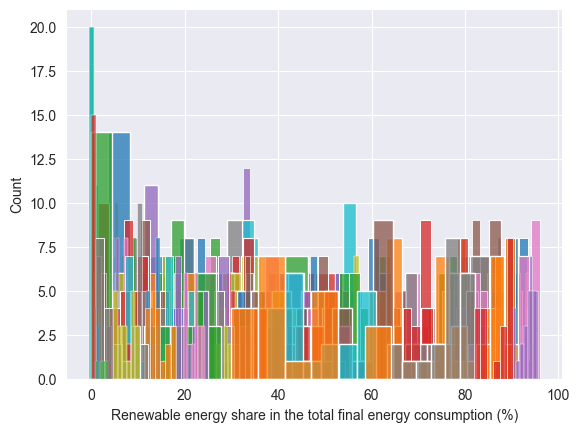

In [95]:
for i in df[df['Renewable energy share in the total final energy consumption (%)'].isna()]['Entity'].unique():
    sns.histplot(df[df['Renewable energy share in the total final energy consumption (%)'].notna() & (df['Entity'] == i)]['Renewable energy share in the total final energy consumption (%)'])

In [96]:
missing_counts

Entity
Afghanistan             1
Albania                21
Algeria                 1
Angola                  1
Antigua and Barbuda     1
                       ..
Uruguay                 1
Uzbekistan              1
Vanuatu                 1
Yemen                   1
Zambia                  1
Length: 174, dtype: int64

In [97]:
df[(df['Entity'] == 'Afghanistan') & df['Renewable energy share in the total final energy consumption (%)'].notna()]['Renewable energy share in the total final energy consumption (%)']

0     44.99
1     45.60
2     37.83
3     36.66
4     44.24
5     33.88
6     31.89
7     28.78
8     21.17
9     16.53
10    15.15
11    12.61
12    15.36
13    16.86
14    18.93
15    17.53
16    19.92
17    19.21
18    17.96
19    18.51
Name: Renewable energy share in the total final energy consumption (%), dtype: float64

The distributions look relatively stable per country (not strongly trending), so we use the median per country to fill the missing values.

In [98]:
col = 'Renewable energy share in the total final energy consumption (%)'
for i in emptylist:
    df.loc[df['Entity'] == i, col] = df.loc[df['Entity'] == i, col].fillna(np.median(df[(df['Entity'] == i) & df[col].notna()][col]))

In [99]:
df['Renewable energy share in the total final energy consumption (%)'].isna().sum()

np.int64(21)

In [100]:
df[df['Renewable energy share in the total final energy consumption (%)'].isna()]

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),gdp_growth,gdp_per_capita
21,Albania,2000,100.00,NaN,9029.4375,4.13,6.946217,1126.683340
22,Albania,2001,100.00,NaN,8635.5320,3.89,8.293313,1281.659826
23,Albania,2002,100.00,NaN,9443.5550,4.10,4.536524,1425.124219
24,Albania,2003,100.00,NaN,10756.6120,3.80,5.528637,1846.120121
25,Albania,2004,100.00,NaN,11586.9510,3.96,5.514668,2373.581292
26,Albania,2005,100.00,NaN,11545.6160,3.75,5.526424,2673.786584
27,Albania,2006,100.00,NaN,10976.7280,3.46,5.902659,2972.742924
28,Albania,2007,100.00,NaN,9534.8740,3.12,5.983260,3595.038057
29,Albania,2008,100.00,NaN,10499.3280,3.01,7.500041,4370.539925
30,Albania,2009,100.00,NaN,11524.4280,2.98,3.354289,4114.134899


The remaining missing values cannot be imputed (the country has no Renewable Share data at all in the dataset), so we drop those rows.

In [101]:
df = df.drop(range(21,42))

In [102]:
df['Renewable energy share in the total final energy consumption (%)'].isna().sum()

np.int64(0)

In [103]:
df.isna().sum()

Entity                                                                0
Year                                                                  0
Access to electricity (% of population)                               0
Renewable energy share in the total final energy consumption (%)      0
Primary energy consumption per capita (kWh/person)                    0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         205
gdp_growth                                                          316
gdp_per_capita                                                      281
dtype: int64

### Energy intensity level of primary energy (MJ/$2017 PPP GDP)   

In [104]:
df[df['Energy intensity level of primary energy (MJ/$2017 PPP GDP)'].notna()]['Entity'].unique()[:5]

<StringArray>
['Afghanistan', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina']
Length: 5, dtype: str

In [105]:
df[df['Entity'] == 'Afghanistan']

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),gdp_growth,gdp_per_capita
0,Afghanistan,2000,1.613591,44.990,302.59482,1.64,NaN,NaN
1,Afghanistan,2001,4.074574,45.600,236.89185,1.74,NaN,NaN
2,Afghanistan,2002,9.409158,37.830,210.86215,1.40,NaN,179.426579
3,Afghanistan,2003,14.738506,36.660,229.96822,1.40,8.832278,190.683814
4,Afghanistan,2004,20.064968,44.240,204.23125,1.20,1.414118,211.382074
5,Afghanistan,2005,25.390894,33.880,252.06912,1.41,11.229715,242.031313
6,Afghanistan,2006,30.718690,31.890,304.42090,1.50,5.357403,263.733602
7,Afghanistan,2007,36.051010,28.780,354.27990,1.53,13.826320,359.693158
8,Afghanistan,2008,42.400000,21.170,607.83350,1.94,3.924984,364.663542
9,Afghanistan,2009,46.740050,16.530,975.04816,2.25,21.390528,437.268740


We check the distribution and trend of Energy Intensity to choose the right imputation method.

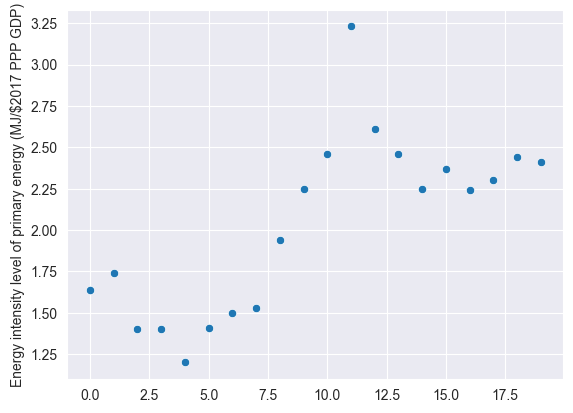

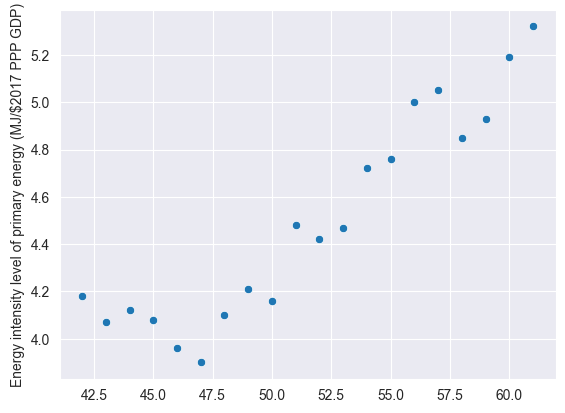

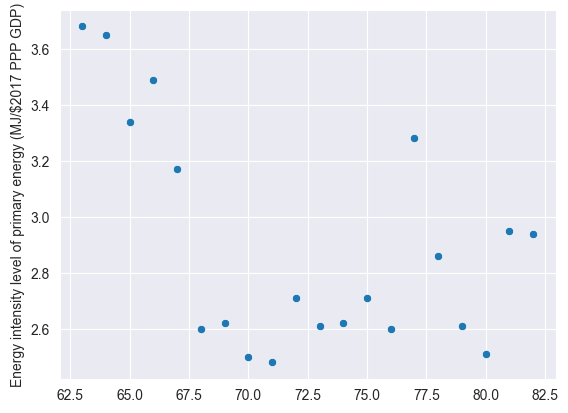

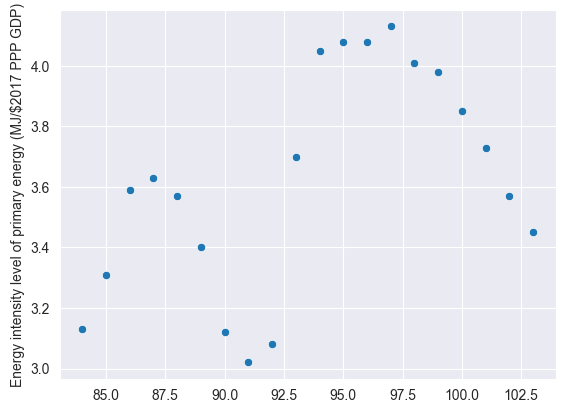

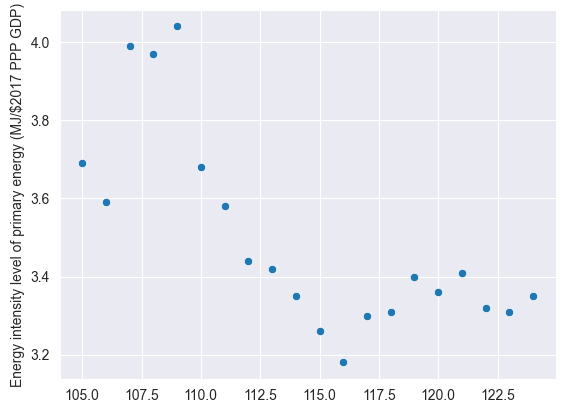

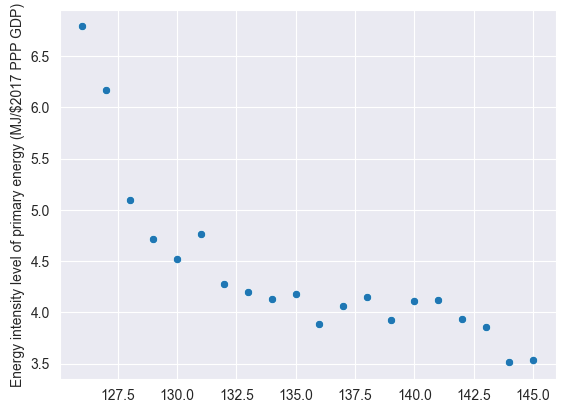

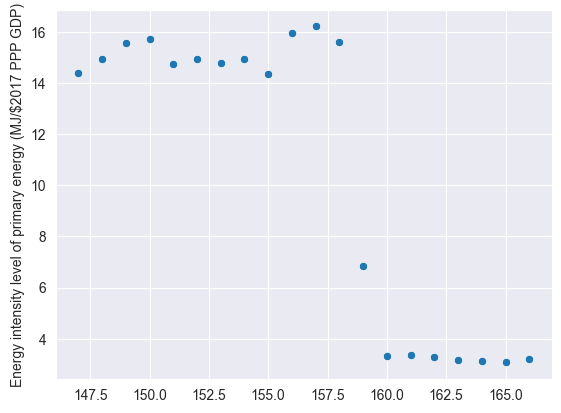

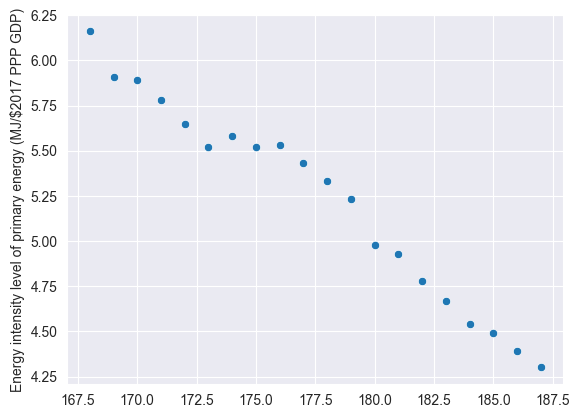

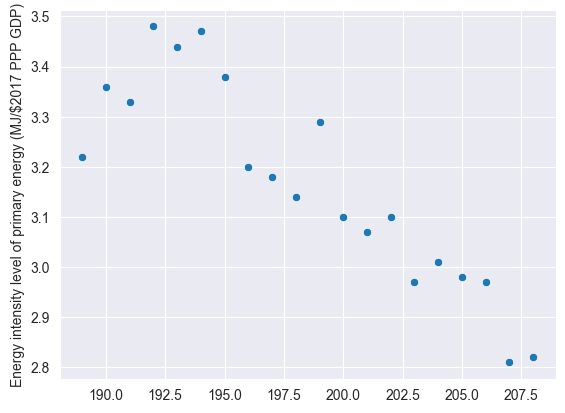

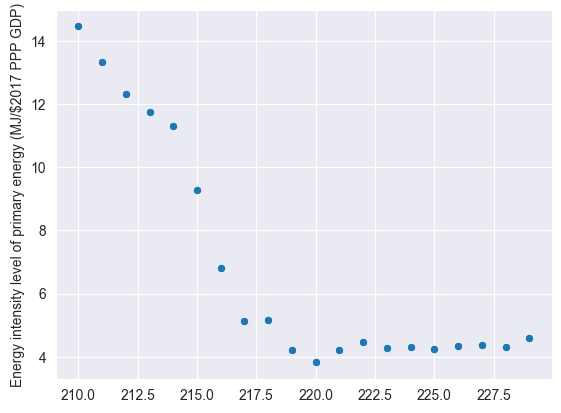

In [106]:
col = 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)'
for i in df[df[col].notna()]['Entity'].unique()[:10]:
    plt.figure()
    sns.scatterplot(df[df['Entity'] == i][col])

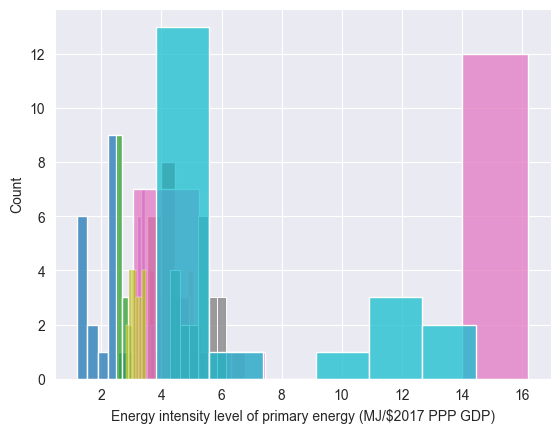

In [107]:
col = 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)'
for i in df[df[col].notna()]['Entity'].unique()[:10]:
    sns.histplot(df[df['Entity'] == i][col])

In [108]:
col = 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)'
df[df[col].isna()].groupby('Entity').size()

Entity
Afghanistan            1
Algeria                1
Angola                 1
Antigua and Barbuda    1
Argentina              1
                      ..
Uruguay                1
Uzbekistan             1
Vanuatu                1
Yemen                  5
Zambia                 1
Length: 173, dtype: int64

In [109]:
col = 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)'
missing_counts = df[df[col].isna()].groupby('Entity').size()
imputelist = missing_counts[missing_counts < 10].index.tolist()
imputelist

['Afghanistan',
 'Algeria',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guatemala',
 'Guinea',
 'Guinea-Bissau',
 'Guyana',
 'Haiti',
 'Honduras',
 'Hungary',
 'Iceland',
 'India',
 'Indonesia',
 'Iraq',
 'Ireland',
 'Israel',
 

We use linear interpolation to fill the gaps between known years. This works only for countries that have enough data (less than 10 missing values, meaning more than 50% of years are filled).

In [110]:
for i in imputelist:
    df.loc[df['Entity'] == i, col] = df.loc[df['Entity'] == i, col].interpolate(
        method='linear', limit_direction='both'
    )

In [111]:
df['Energy intensity level of primary energy (MJ/$2017 PPP GDP)'].isna().sum()

np.int64(21)

### gdp_growth

In [112]:
df['gdp_growth'].isna().sum()

np.int64(316)

In [113]:
df[df['gdp_growth'].notna() & (df['Entity'] == 'Afghanistan')]['gdp_growth']

3      8.832278
4      1.414118
5     11.229715
6      5.357403
7     13.826320
8      3.924984
9     21.390528
10    14.362441
11     0.426355
12    12.752287
13     5.600745
14     2.724543
15     1.451315
16     2.260314
17     2.647003
18     1.189228
19     3.911603
20    -2.351101
Name: gdp_growth, dtype: float64

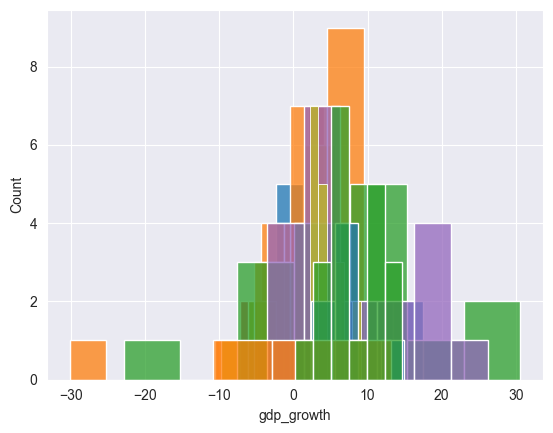

In [114]:
for i in df[df['gdp_growth'].isna()]['Entity'].unique():
    sns.histplot(df[df['gdp_growth'].notna() & (df['Entity'] == i)]['gdp_growth'])

The graph above shows a right-skewed distribution on gdp_growth which are not missing, this mean the data are not meanly/normally distributed (there are outliers which affecting the mean). So, median is used to avoid the effect from outliers in imputing missing datas, the median will be taken from different unique countries. Meaning the missing data from a country, will be imputed by the median of that country aswell

In [115]:
df[df['gdp_growth'].isna()].groupby('Entity').size()

Entity
Afghanistan                          3
Aruba                                3
Bahamas                             21
Cayman Islands                       7
Congo                               21
Czechia                             21
Djibouti                            14
Egypt                               21
Eritrea                              9
Gambia                              21
Kyrgyzstan                          21
Liberia                              1
Nauru                                5
New Caledonia                       20
Qatar                                1
Saint Kitts and Nevis               21
Saint Lucia                         21
Saint Vincent and the Grenadines    21
Sao Tome and Principe                2
Slovakia                            21
Somalia                             14
South Sudan                          5
Turkmenistan                         1
Yemen                               21
dtype: int64

In [116]:
missing_counts = df[df['gdp_growth'].isna()].groupby('Entity').size()
imputelist = missing_counts[missing_counts < 10].index.tolist()
imputelist

['Afghanistan',
 'Aruba',
 'Cayman Islands',
 'Eritrea',
 'Liberia',
 'Nauru',
 'Qatar',
 'Sao Tome and Principe',
 'South Sudan',
 'Turkmenistan']

In [117]:
col = 'gdp_growth'
for i in imputelist:
    df.loc[df['Entity'] == i, col] = df.loc[df['Entity'] == i, col].fillna(np.median(df[df[col].notna() & (df['Entity'] == i)]['gdp_growth']))

In [118]:
df['gdp_growth'].isna().sum()

np.int64(279)

In [119]:
droplist = df[df['gdp_growth'].isna()]['Entity'].unique().tolist()
droplist

['Bahamas',
 'Congo',
 'Czechia',
 'Djibouti',
 'Egypt',
 'Gambia',
 'Kyrgyzstan',
 'New Caledonia',
 'Saint Kitts and Nevis',
 'Saint Lucia',
 'Saint Vincent and the Grenadines',
 'Slovakia',
 'Somalia',
 'Yemen']

Countries with many missing values for gdp_growth are dropped, since imputation would not be reliable.

In [120]:
for i in droplist:
    df = df.drop(df[df['Entity'] == i].index)

In [121]:
df['gdp_growth'].isna().sum()

np.int64(0)

### gdp_per_capita

In [122]:
(df[df['gdp_per_capita'].notna() & (df['Entity'] == 'Afghanistan')]['gdp_per_capita'].count())

np.int64(19)

It can be seen from the scatter plot below that the gdp_per_capita is rising over years, we can use linear regression for this imputation

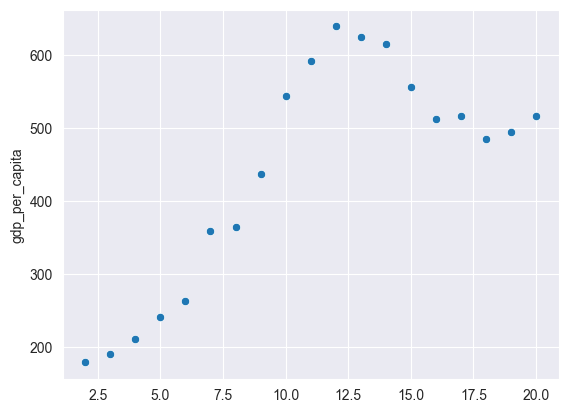

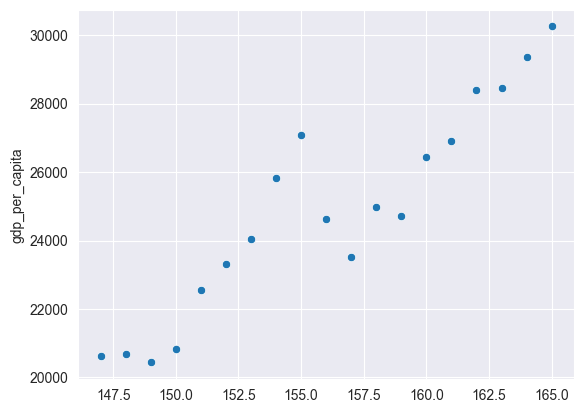

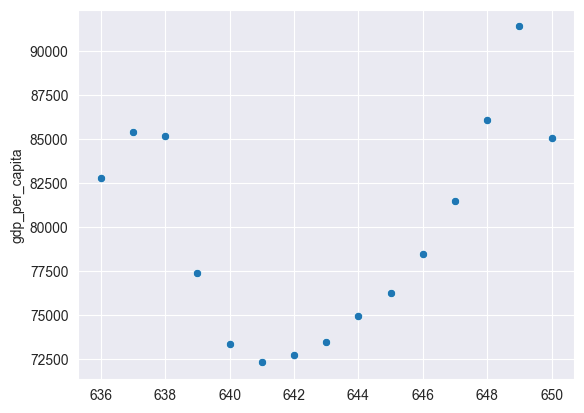

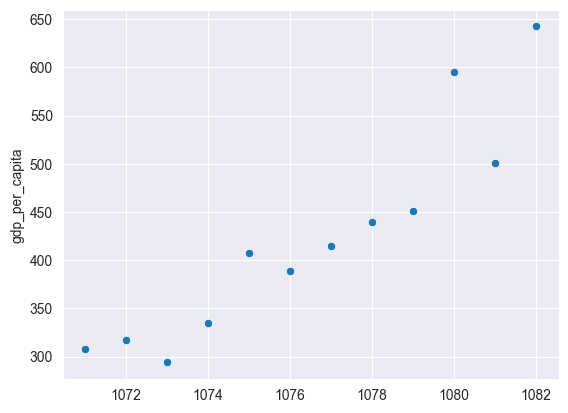

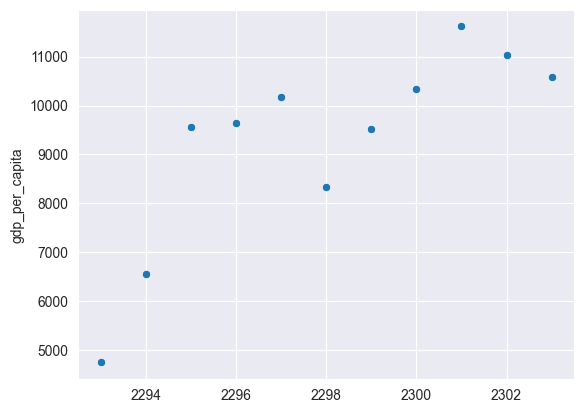

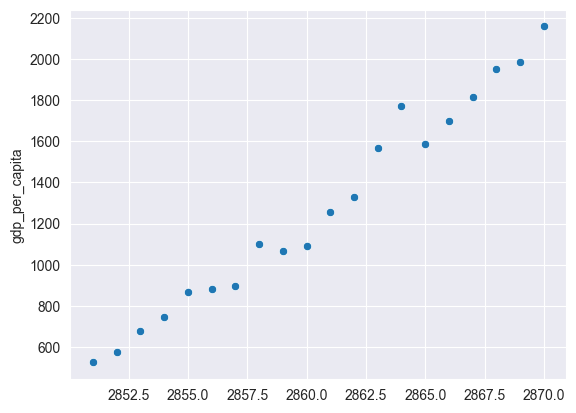

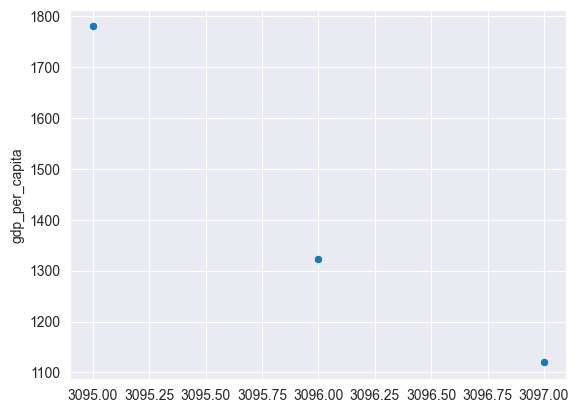

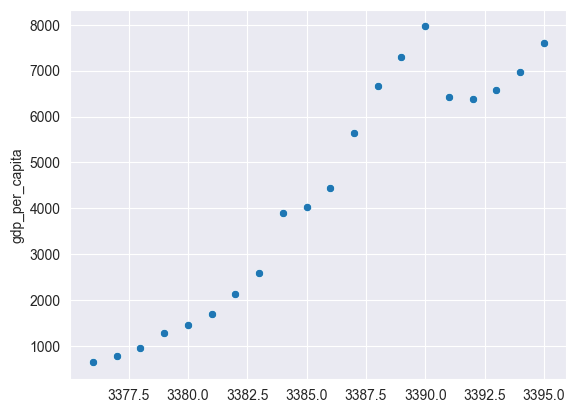

In [123]:
for i in df[df['gdp_per_capita'].isna()]['Entity'].unique():
    plt.figure()
    sns.scatterplot(df[df['gdp_per_capita'].notna() & (df['Entity'] == i)]['gdp_per_capita'])

impute_gdp_c is a variable which stores entities who has data of gdp_per_capita more than 5

In [124]:
impute_gdp_c = []
for i in df[df['gdp_per_capita'].isna()]['Entity'].unique():
    if (df[df['gdp_per_capita'].notna() & (df['Entity'] == i)]['gdp_per_capita'].count()) > 5:
        impute_gdp_c.append(i)

Since gdp_per_capita rises steadily over the years, we use Linear Regression to predict the missing values for each country.

In [125]:
from sklearn.linear_model import LinearRegression

for i in impute_gdp_c:
    lm = LinearRegression()
    data_train = df[(df['Entity'] == i) & (df['gdp_per_capita'].notna())]
    X_train = data_train[['Year']]
    y_train = data_train['gdp_per_capita']

    lm.fit(X_train, y_train)
    data_missing = df[(df['Entity'] == i) & (df['gdp_per_capita'].isna())]
    
    #cek apakah ada baris yang kosong atau tidak
    if not data_missing.empty:
        X_test = data_missing[['Year']]
        predictions = lm.predict(X_test)
        df.loc[data_missing.index, 'gdp_per_capita'] = predictions
    else:
        continue

these remaining missing values meaning the countries doesn't have more than 5 data of gdp_per_capita, which we can't impute them because the lack of data

In [126]:
df['gdp_per_capita'].isna().sum()

np.int64(5)

In [127]:
df[df['gdp_per_capita'].isna()]

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),gdp_growth,gdp_per_capita
3098,South Sudan,2016,5.117368,28.79,698.38540,1.086098,3.373648,NaN
3099,South Sudan,2017,4.200000,28.63,635.44260,1.086098,3.373648,NaN
3100,South Sudan,2018,6.173170,28.65,671.75750,1.086098,3.373648,NaN
3101,South Sudan,2019,6.707007,26.65,747.48596,1.086098,3.373648,NaN
3102,South Sudan,2020,7.241338,28.65,703.13510,1.086098,3.373648,NaN


South Sudan has too many missing values to impute reliably, so we drop it.

In [128]:
for i in droplist:
    df = df.drop(df[df['Entity'] == 'South Sudan'].index)

### Cleaned Data

In [129]:
df.isna().sum()

Entity                                                              0
Year                                                                0
Access to electricity (% of population)                             0
Renewable energy share in the total final energy consumption (%)    0
Primary energy consumption per capita (kWh/person)                  0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         0
gdp_growth                                                          0
gdp_per_capita                                                      0
dtype: int64

In [130]:
df

,Entity,Year,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),gdp_growth,gdp_per_capita
0,Afghanistan,2000,1.613591,44.99,302.59482,1.64,3.918294,202.136686
1,Afghanistan,2001,4.074574,45.60,236.89185,1.74,3.918294,223.674784
2,Afghanistan,2002,9.409158,37.83,210.86215,1.40,3.918294,179.426579
3,Afghanistan,2003,14.738506,36.66,229.96822,1.40,8.832278,190.683814
4,Afghanistan,2004,20.064968,44.24,204.23125,1.20,1.414118,211.382074
...,...,...,...,...,...,...,...,...
3644,Zimbabwe,2016,42.561730,81.90,3227.68020,10.00,0.755869,1464.588957
3645,Zimbabwe,2017,44.178635,82.46,3068.01150,9.51,4.709492,1235.189032
3646,Zimbabwe,2018,45.572647,80.23,3441.98580,9.83,4.824211,1254.642265
3647,Zimbabwe,2019,46.781475,81.50,3003.65530,10.47,-6.144236,1316.740657


### After cleaning and imputation:

- **3,325 rows** across **159 countries** from **2000 to 2020**
- **6 variables**: Access to Electricity, Renewable Share, Energy Intensity, Energy per Capita, GDP Growth, GDP per Capita
- **0 missing values** remaining

The cleaned data is now saved as `datacleanfinal.csv` for use in the visualization stage.

In [131]:
df.to_csv('cleaned_dataset.csv')

## Data Visualization & Insights

For easier reading in plots, we rename the long column names to shorter labels.

In [132]:
df = df.rename(columns={
    'Access to electricity (% of population)': 'Access to Electricity',
    'Renewable energy share in the total final energy consumption (%)': 'Renewable Share',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)': 'Energy Intensity',
    'Primary energy consumption per capita (kWh/person)': 'Energy per Capita',
    'gdp_growth': 'GDP Growth',
    'gdp_per_capita': 'GDP per Capita',
})

### Correlation Between All Variables

Before going into specific insights, we check the correlation matrix between all numeric variables to find which relationships to be explore.

In [133]:
df.select_dtypes('number').corr()

,Year,Access to Electricity,Renewable Share,Energy per Capita,Energy Intensity,GDP Growth,GDP per Capita
Year,1.000000,0.137893,-0.027408,0.004829,-0.171825,-0.194882,0.129592
Access to Electricity,0.137893,1.000000,-0.789653,0.454313,-0.266693,-0.104998,0.417719
Renewable Share,-0.027408,-0.789653,1.000000,-0.437210,0.225014,0.081684,-0.369765
Energy per Capita,0.004829,0.454313,-0.437210,1.000000,0.138392,-0.032556,0.661383
Energy Intensity,-0.171825,-0.266693,0.225014,0.138392,1.000000,0.094089,-0.193702
GDP Growth,-0.194882,-0.104998,0.081684,-0.032556,0.094089,1.000000,-0.126708
GDP per Capita,0.129592,0.417719,-0.369765,0.661383,-0.193702,-0.126708,1.000000


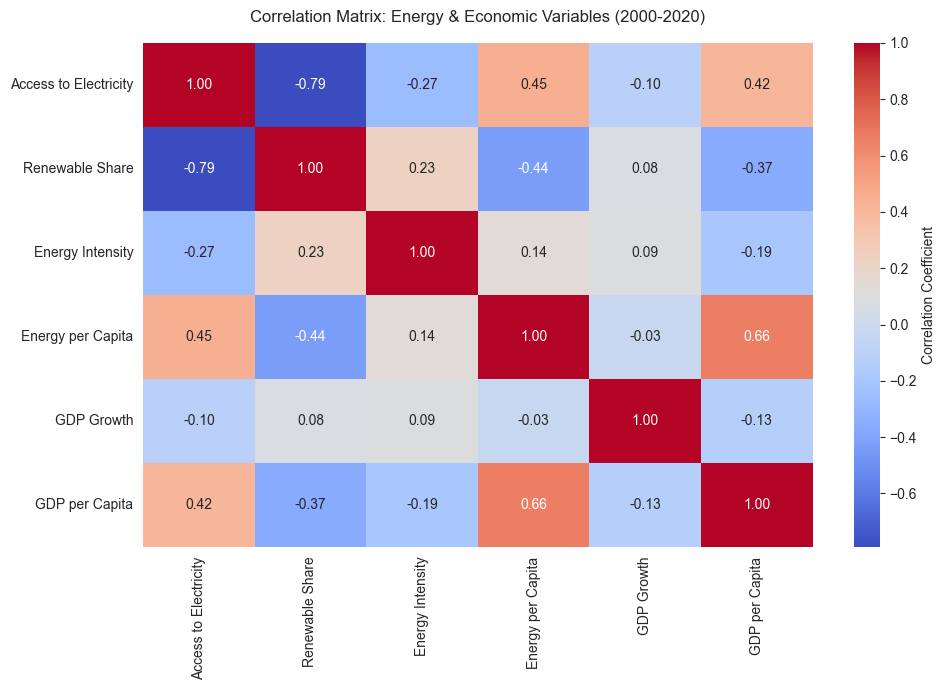

In [134]:
numeric_cols = ['Access to Electricity', 'Renewable Share', 'Energy Intensity',
                'Energy per Capita', 'GDP Growth', 'GDP per Capita']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap = 'coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix: Energy & Economic Variables (2000-2020)', pad=15)
plt.tight_layout()
plt.show()

**Key observations from the heatmap:**

1. **Access to Electricity with Renewable Share: -0.79 (strongest negative)**  
   Strong negative correlation. As electricity access increases, renewable share decreases.

2. **Energy per Capita with GDP per Capita: +0.66 (strongest positive)**  
   Strong positive correlation. Higher GDP per capita meaning higher energy consumption per person.

3. **GDP Growth: weak correlations with all energy variables (|r| < 0.13)**  
   No meaningful linear relationship between yearly GDP growth and any energy variable.

### Insight 1: Why Poor Countries Have the Highest Renewable Share

The heatmap shows a high negative correlation between Access to Electricity and Renewable Share (-0.79). Logically this doesn't make sense because developed countries should have more solar panels and wind farms which results in higher renewable share

We group countries into 5 categories based on their Access to Electricity, then look at the average Renewable Share for each group.

In [135]:
df['access_bin'] = pd.cut(
    df['Access to Electricity'],
    bins=[-0.01, 25, 50, 75, 99, 100.01],
    labels=['<25%', '25-50%', '50-75%', '75-99%', '~100%']
)


access_summary = df.groupby('access_bin', observed=True).agg(
    avg_renewable=('Renewable Share', 'mean'),
    median_renewable=('Renewable Share', 'median'),
    n_rows=('Renewable Share', 'count')
).round(2)

print(access_summary)

            avg_renewable  median_renewable  n_rows
access_bin                                         
<25%                80.90             84.37     361
25-50%              65.75             74.22     356
50-75%              50.05             48.64     289
75-99%              28.04             24.70     754
~100%               14.59              9.03    1565


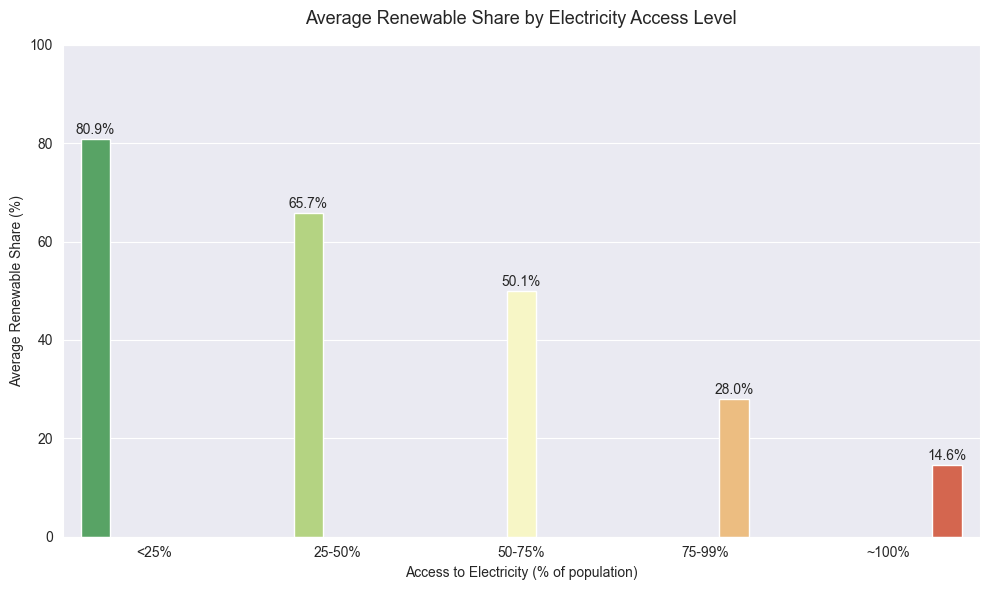

In [136]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x='access_bin',
    y='Renewable Share',
    estimator='mean',
    errorbar=None,
    palette='RdYlGn_r',
    hue='access_bin',
    legend=False
)


for i in ax.patches:
    ax.text(
        x=i.get_x() + i.get_width()/2,
        y=i.get_height() + 1,
        s=f'{i.get_height():.1f}%',
        ha='center',
    )

plt.title('Average Renewable Share by Electricity Access Level', fontsize=13, pad=15)
plt.xlabel('Access to Electricity (% of population)')
plt.ylabel('Average Renewable Share (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Chart Insights:**

Countries with the lowest electricity access (<25%) have an average renewable share of **80.9%**, while countries with full access (~100%) only have **14 6%**. The graph shows a linear pattern where the lower the access to electricity, the higher the renewable share.

**Why & How can this happen?**

Logically, this won't be possible because country which have few Access to Electricity tends to have a low power grid, so we're assumpting the country might be use traditional natural resources such as wood, charcoal, etc used for daily routines & needs such as cooking, heating, etc. Which are considered as renewable energy as well even it's not the same as solar panels, wind turbines, or any renewable energy generator.

### Insight 2: Richer Countries Consume Far More Energy

The second strongest correlation in the heatmap is Energy per Capita with GDP per Capita (+0.66).

We aggregate the data per country (averaging across years), then plot GDP per Capita against Energy per Capita using a log scale on both axes to handle the wide range of values.

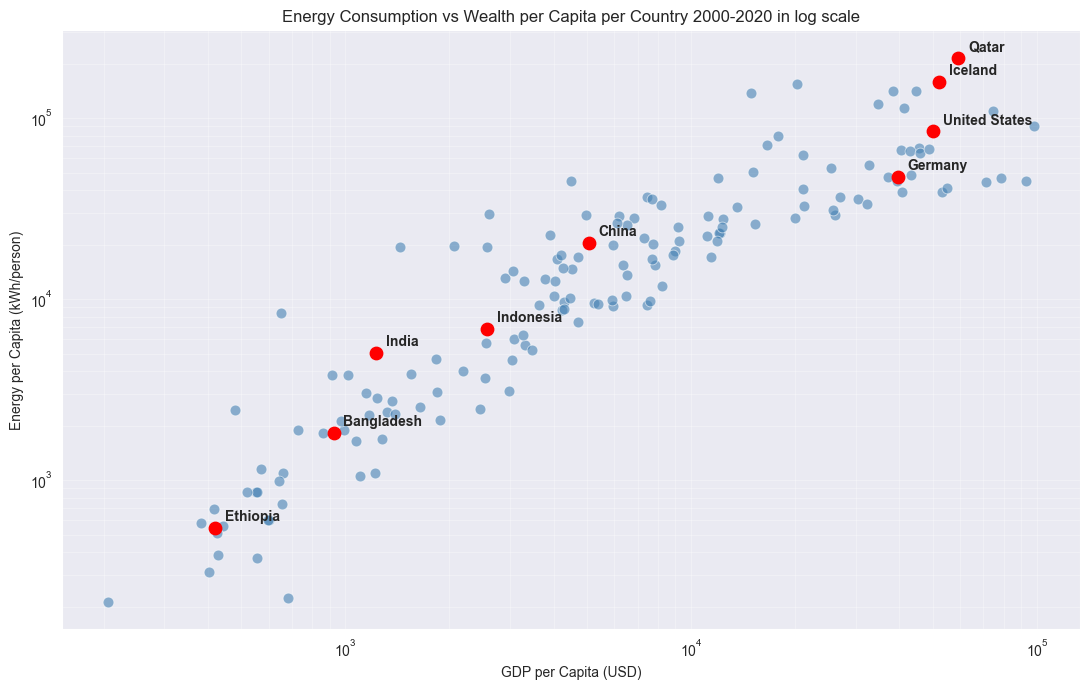

In [137]:
df_country = df.groupby('Entity').agg(
    avg_gdp_pc=('GDP per Capita', 'mean'),
    avg_energy_pc=('Energy per Capita', 'mean')
).reset_index()

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_country,
    x='avg_gdp_pc',
    y='avg_energy_pc',
    alpha=0.6,
    s=60,
    color='steelblue',
    edgecolor='white'
)

highlight = ['Qatar', 'Iceland', 'United States', 'Germany', 'China', 
             'India', 'Indonesia', 'Ethiopia', 'Bangladesh']
for country in highlight:
    row = df_country[df_country['Entity'] == country]
    if not row.empty:
        plt.scatter(row['avg_gdp_pc'], row['avg_energy_pc'], 
                   color='red', s=80, zorder=5)
        plt.annotate(country, 
                    (row['avg_gdp_pc'].values[0], row['avg_energy_pc'].values[0]),
                    xytext=(7, 5), textcoords='offset points',
                    fontweight='bold')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Energy per Capita (kWh/person)')
plt.title('Energy Consumption vs Wealth per Capita per Country 2000-2020 in log scale')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

To make the gap easier to understand, we compare the energy consumption of the richest 10% of countries to the poorest 10%.

In [138]:
top10_threshold = df_country['avg_gdp_pc'].quantile(0.9)
bot10_threshold = df_country['avg_gdp_pc'].quantile(0.1)

top10_energy = df_country[df_country['avg_gdp_pc'] >= top10_threshold]['avg_energy_pc'].mean()
bot10_energy = df_country[df_country['avg_gdp_pc'] <= bot10_threshold]['avg_energy_pc'].mean()

print(f"Top 10% richest countries: avg energy = {top10_energy:,.0f} kWh/person")
print(f"Bottom 10% poorest countries: avg energy = {bot10_energy:,.0f} kWh/person")
print(f'Gap: {top10_energy/bot10_energy:,.0f}x')

Top 10% richest countries: avg energy = 83,052 kWh/person
Bottom 10% poorest countries: avg energy = 721 kWh/person
Gap: 115x


**Chart Insights:**

There is a uptrend where as GDP per capita rises, energy consumption per person rises too. All the points form an upward linear line on the log scale, which means the relationship is multiplicative meaning that every time the wealth doubles, the energy consumes also doubles.

The richest 10% of countries (Qatar, Iceland, etc) use around **115 times more energy per person** than the poorest 10% (Ethiopia, Bangladesh, etc).

### Insight 3: Are Countries Becoming More Efficient?

Energy intensity tells us how much energy a country uses to produce $1 of GDP. Lower intensity = more efficient.

We group countries by income level using the **World Bank classification**:  
(Link: https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups)

- Low Income: < \$1,135
- Lower-Middle Income: \$1,135 – \$4,465
- Upper-Middle Income: \$4,465 – \$13,845
- High Income: > \$13,845

In [139]:
df['income_group'] = pd.cut(
    df['GDP per Capita'],
    bins=[0, 1135, 4465, 13845, float('inf')],
    labels=['Low Income', 'Lower-Middle', 'Upper-Middle', 'High Income']
)

print(df.groupby('income_group', observed=True).size())

income_group
Low Income      728
Lower-Middle    904
Upper-Middle    786
High Income     907
dtype: int64


We calculate the average Energy Intensity for each income group per year, then measure how much each group improved from 2000 to 2020.

In [140]:
yearly_intensity = df.groupby(['Year', 'income_group'], observed=True)['Energy Intensity'].mean().reset_index()


change_summary = []
for grp in yearly_intensity['income_group'].unique():
    sub = yearly_intensity[yearly_intensity['income_group'] == grp]
    v2000 = sub[sub['Year'] == 2000]['Energy Intensity'].values[0]
    v2020 = sub[sub['Year'] == 2020]['Energy Intensity'].values[0]
    change = v2000 - v2020
    pct_change = (change / v2000) * -100
    change_summary.append({
        'Income Group': grp,
        '2000': round(v2000, 2),
        '2020': round(v2020, 2),
        '% Drop': round(pct_change, 1)
    })

change_df = pd.DataFrame(change_summary)
print(change_df)


gap_2000 = change_df[change_df['Income Group'] == 'Low Income']['2000'].values[0] - \
           change_df[change_df['Income Group'] == 'High Income']['2000'].values[0]
gap_2020 = change_df[change_df['Income Group'] == 'Low Income']['2020'].values[0] - \
           change_df[change_df['Income Group'] == 'High Income']['2020'].values[0]
print(f"\nGap (Low - High) in 2000: {gap_2000:.2f}")
print(f"Gap (Low - High) in 2020: {gap_2020:.2f}")
print(f"Gap change: {gap_2020 - gap_2000:+.2f}")

   Income Group  2000  2020  % Drop
0    Low Income  8.80  6.69   -24.0
1  Lower-Middle  5.04  4.69    -6.9
2  Upper-Middle  5.00  3.92   -21.5
3   High Income  4.91  4.03   -18.0

Gap (Low - High) in 2000: 3.89
Gap (Low - High) in 2020: 2.66
Gap change: -1.23


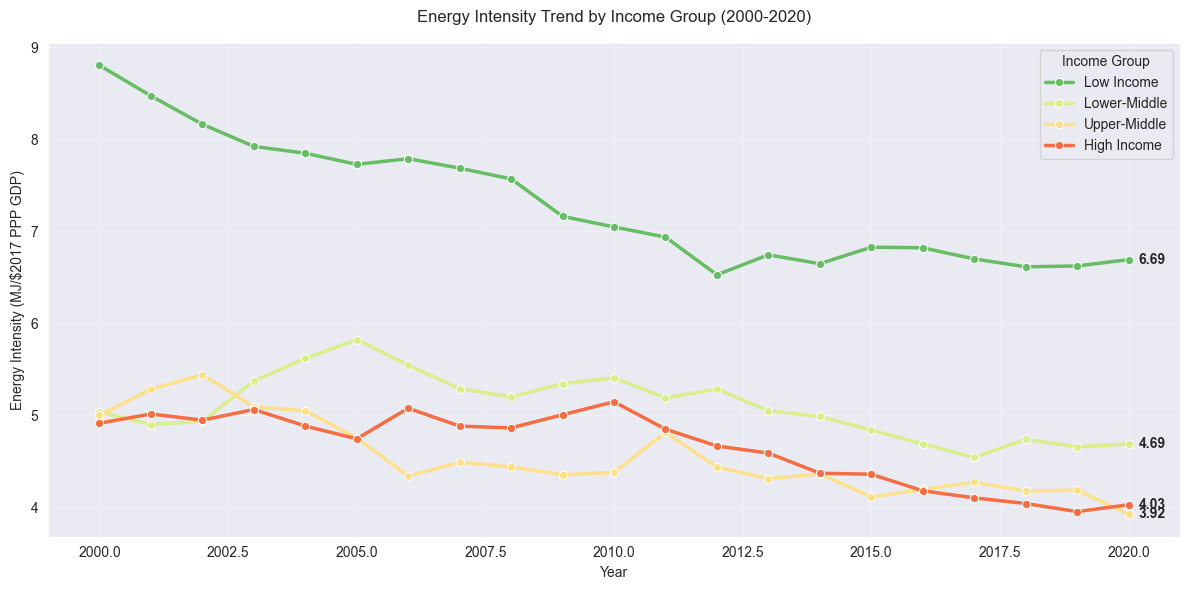

In [141]:
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=yearly_intensity,
    x='Year',
    y='Energy Intensity',
    hue='income_group',
    marker='o',
    linewidth=2.5,
    palette='RdYlGn_r'
)


data_2020 = yearly_intensity[yearly_intensity['Year'] == 2020]
for _, row in data_2020.iterrows():
    ax.text(
        x=2020.2,
        y=row['Energy Intensity'],
        s=f"{row['Energy Intensity']:.2f}",
        fontsize=10,
        fontweight='bold',
        va='center'
    )

plt.title('Energy Intensity Trend by Income Group (2000-2020)', pad=15)
plt.xlabel('Year')
plt.ylabel('Energy Intensity (MJ/$2017 PPP GDP)')
plt.legend(title='Income Group', loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Chart Insights:**

All four income groups reduced their energy intensity between 2000 and 2020 which means that the world is becoming more efficient at using energy to improve their economy

The biggest improvement came from Low Income countries where they reduces their energy intensity 24%. Meanwhile, Lower-Middle Income countries improved the least by reducing only 6.9%.

### Insight 4: Who Changed Their Renewable Share the Most?

More renewable share meaning more renewable energy are used

We calculate the change in Renewable Share for each country from 2000 to 2020, then pick the top 10 biggest increases (winners) and top 10 biggest decreases (losers).

In [142]:
#renewable share di 2000 dan 2020 per negara
renewable_change = df.pivot_table(
    index='Entity',
    columns='Year',
    values='Renewable Share'
)[[2000, 2020]].dropna()

renewable_change['Change'] = renewable_change[2020] - renewable_change[2000]
renewable_change = renewable_change.reset_index()
renewable_change.columns = ['Entity', 'Renewable_2000', 'Renewable_2020', 'Change']


top_winners = renewable_change.nlargest(10, 'Change')
print("=== TOP 10 Renewable Share INCREASE ===")
print(top_winners.to_string(index=False))

top_losers = renewable_change.nsmallest(10, 'Change')
print("\n=== TOP 10 Renewable Share DECREASE ===")
print(top_losers.to_string(index=False))

=== TOP 10 Renewable Share INCREASE ===
  Entity  Renewable_2000  Renewable_2020  Change
 Iceland           60.66          75.325  14.665
Zimbabwe           69.26          81.900  12.640
   Gabon           72.78          84.440  11.660
Eswatini           59.39          69.655  10.265
 Denmark           10.73          20.265   9.535
 Hungary            5.17          12.875   7.705
 Uruguay           38.73          46.245   7.515
 Germany            3.70          11.165   7.465
   Italy            5.12          12.220   7.100
   Spain            7.88          13.345   5.465

=== TOP 10 Renewable Share DECREASE ===
           Entity  Renewable_2000  Renewable_2020  Change
Equatorial Guinea           45.85           6.785 -39.065
      Afghanistan           44.99          19.565 -25.425
            Ghana           71.62          51.905 -19.715
            Benin           70.29          52.400 -17.890
           Angola           73.44          55.565 -17.875
       Bangladesh           59.0

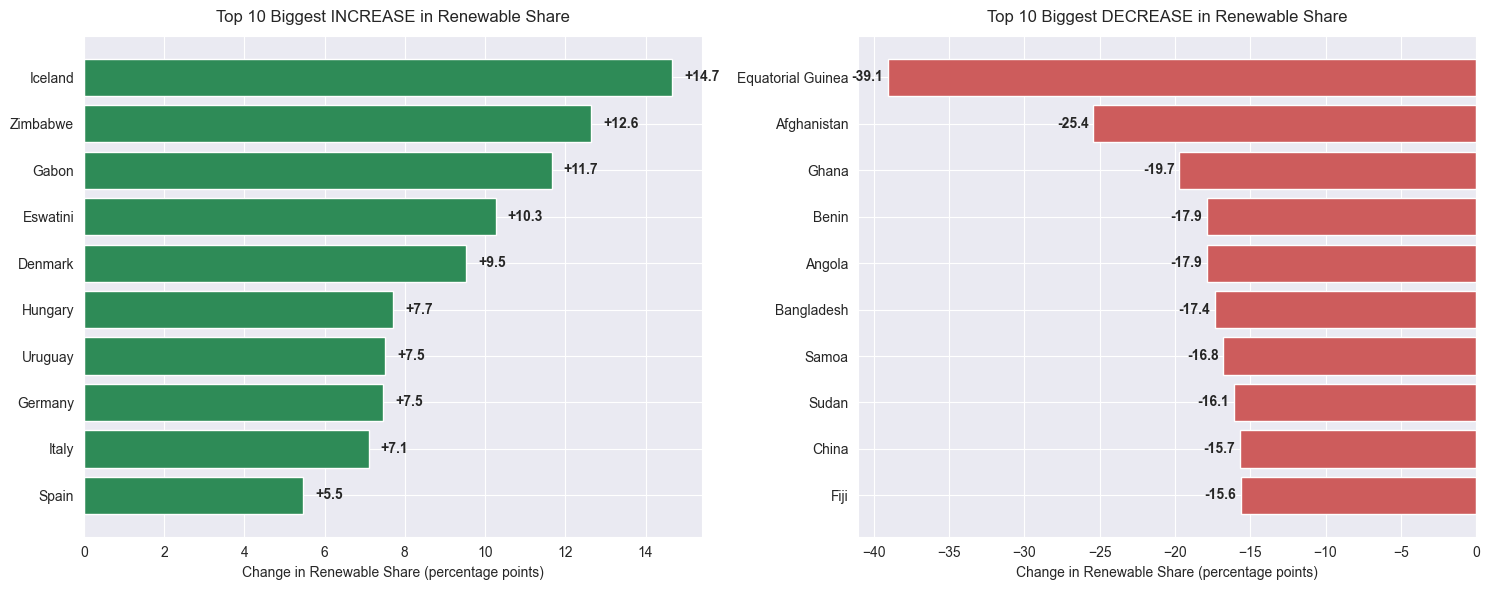

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_winners_sorted = top_winners.sort_values('Change')
axes[0].barh(top_winners_sorted['Entity'], top_winners_sorted['Change'], 
             color='seagreen', edgecolor='white')
axes[0].set_title('Top 10 Biggest INCREASE in Renewable Share', 
                  fontsize=12, pad=10)
axes[0].set_xlabel('Change in Renewable Share (percentage points)')

for i, (entity, val) in enumerate(zip(top_winners_sorted['Entity'], 
                                       top_winners_sorted['Change'])):
    axes[0].text(val + 0.3, i, f'+{val:.1f}', va='center', fontsize=10, fontweight='bold')

top_losers_sorted = top_losers.sort_values('Change', ascending=False)
axes[1].barh(top_losers_sorted['Entity'], top_losers_sorted['Change'], 
             color='indianred', edgecolor='white')
axes[1].set_title('Top 10 Biggest DECREASE in Renewable Share', 
                  fontsize=12, pad=10)
axes[1].set_xlabel('Change in Renewable Share (percentage points)')

for i, (entity, val) in enumerate(zip(top_losers_sorted['Entity'], 
                                       top_losers_sorted['Change'])):
    axes[1].text(val - 0.3, i, f'{val:.1f}', va='center', ha='right', 
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Chart Insights:**

The biggest renewable share increase from 2000 to 2020 came from Iceland (+14.7%), Zimbabwe (+12.6%), and Gabon (+11.7%). The biggest decreases came from Equatorial Guinea (-39.1%), Afghanistan (-25.4%), and Ghana (-19.7%).

Looking at the increasing and decreasing country in renewable shares together, there is no single pattern based on wealth alone. Both rich countries (Iceland, Denmark, Germany) and poor countries (Zimbabwe, Eswatini) appear in the increasing list. Meanwhile, most decreasing ones have low to medium GDP per capita, but Equatorial Guinea (the biggest decreasing) actually has a higher GDP than several winners.

## Conclusion

This analysis looked at how economic and energy data relate to each other across 
159 countries from 2000 to 2020.

### Summary of the insights

**1. Insight 1**
Renewable share goes down while electricity access goes up (r = -0.79). Countries with low electricity access (<25%) have an average renewable share of 80.9%, while countries with full access (~100%) only have 14.6%. The pattern is linear the higher the access to electricity, the lower the renewable share.

**2. Insight 2**
Richer countries use a lot more energy (r = +0.66). The top 10% richest countries use around 115 times more energy per person than the poorest 10%. This means that as poor countries grow richer, global energy use will likely rise a lot.

**3. Insight 3**
All income groups became more efficient from 2000 to 2020. Low Income countries improved the most (-24%), while Lower-Middle Income countries improved the least (-6.9%).

**4. Insight 4**
Increasing and Decreasing country in renewable shares do not follow a simple rich vs poor pattern. Both rich countries (Iceland, Denmark) and poor countries (Zimbabwe, Eswatini) are in the increasing list. Most decreasing are developing countries.